In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **EDA**


In [167]:
df = pd.read_csv('/content/Sales - Marketing customer dataset.csv')

df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [168]:
#informasi
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

(15000, 30)

In [169]:
#mising value
df.isnull().sum()

,0
customer_id,0
gender,738
age,1200
country,0
city,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0


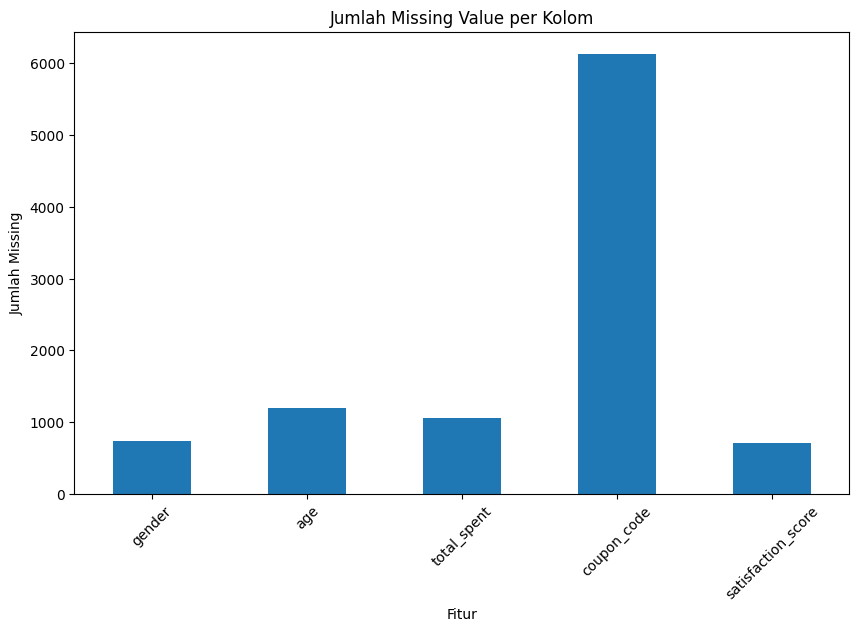

In [170]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

missing = missing[missing > 0]  # hanya kolom yang ada missing

plt.figure(figsize=(10,6))
missing.plot(kind='bar')

plt.title('Jumlah Missing Value per Kolom')
plt.ylabel('Jumlah Missing')
plt.xlabel('Fitur')

plt.xticks(rotation=45)
plt.show()

Missing Value

Berdasarkan pengecekan, ditemukan adanya missing value pada beberapa kolom. Missing value ini perlu ditangani pada tahap preprocessing agar tidak mempengaruhi performa model.

In [171]:
#duplikasi
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplikasi data.

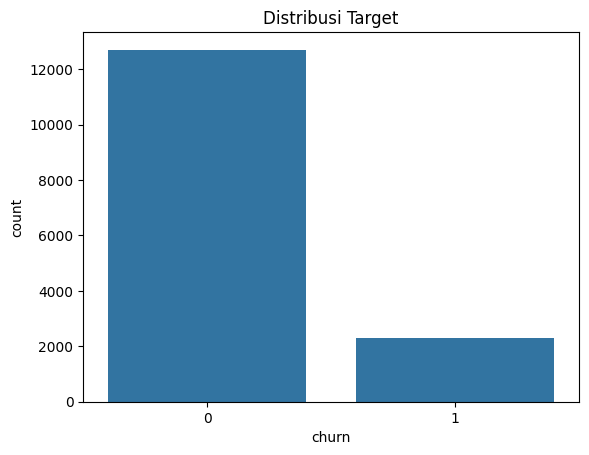

,count
churn,
0,12702
1,2298


In [172]:
#distribusi target
sns.countplot(x='churn', data=df)
plt.title("Distribusi Target")
plt.show()

df['churn'].value_counts()

Distribusi target menunjukkan imbalance

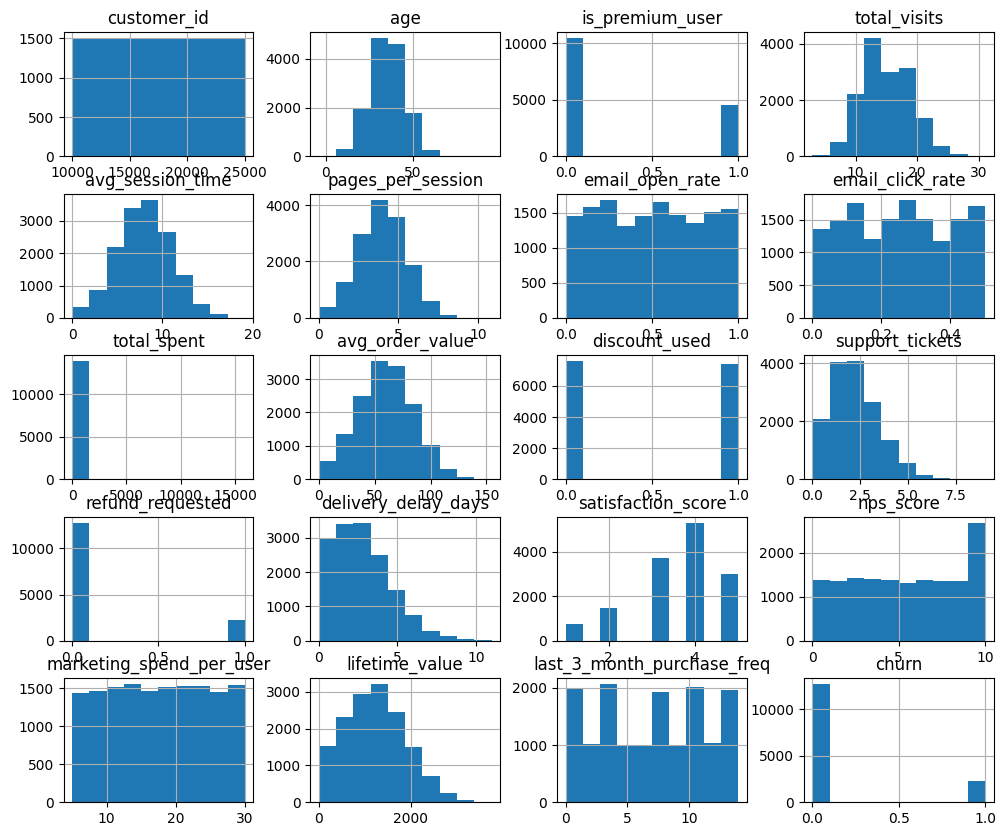

In [173]:
#distribusi numerik
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(12,10))
plt.show()

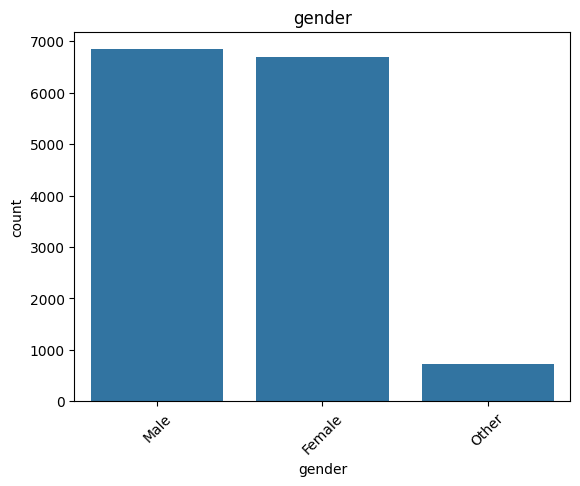

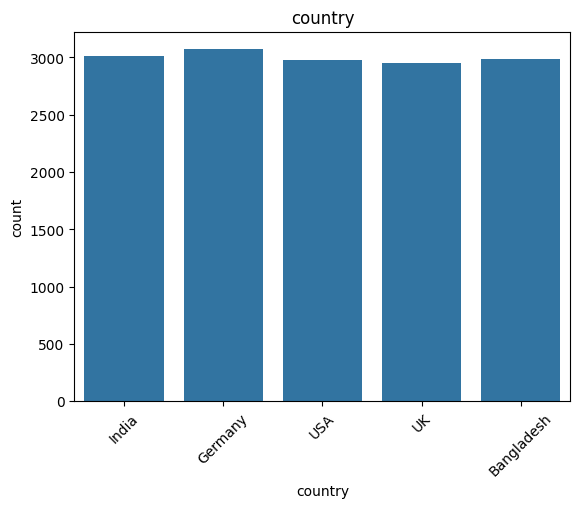

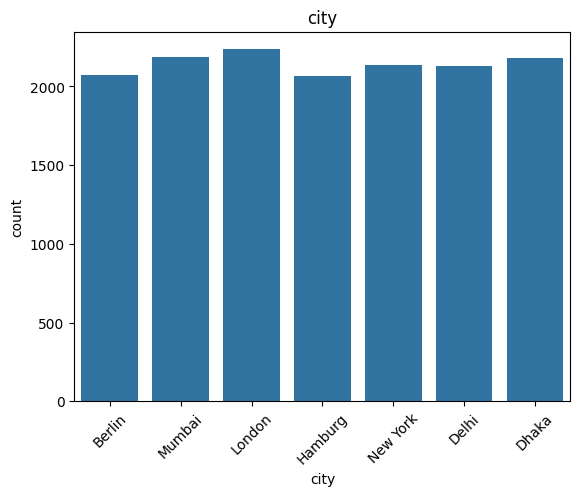

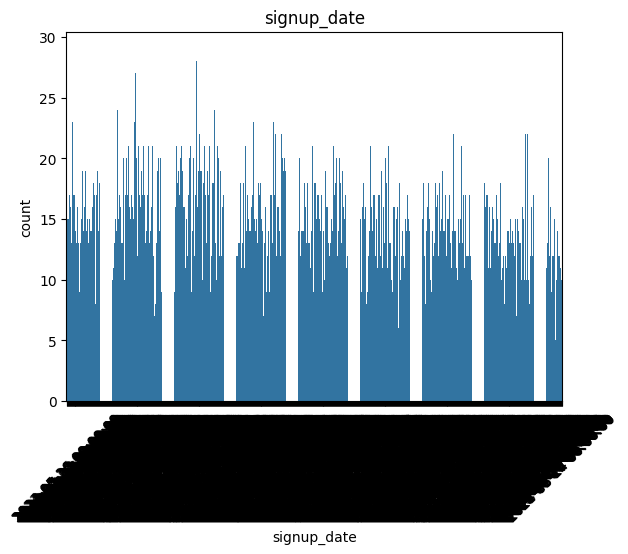

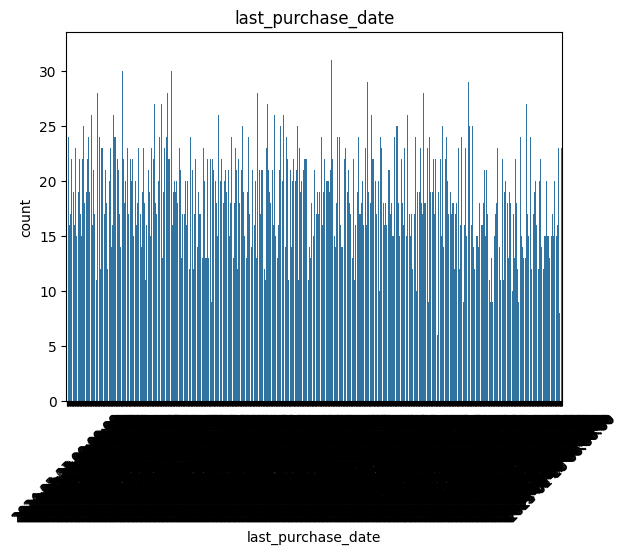

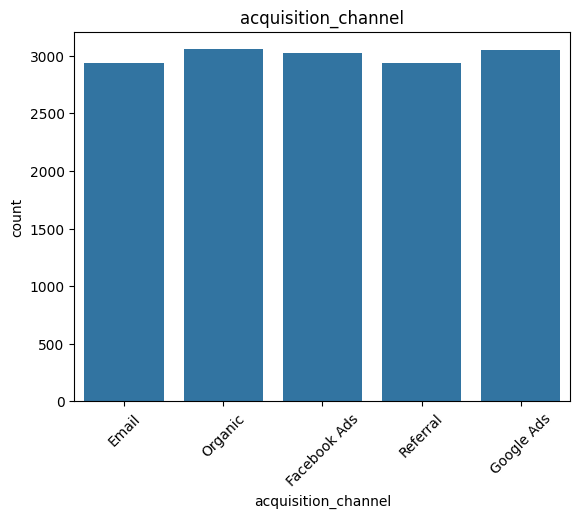

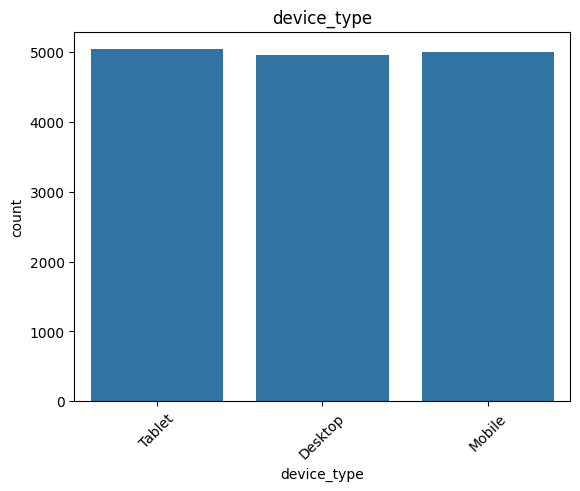

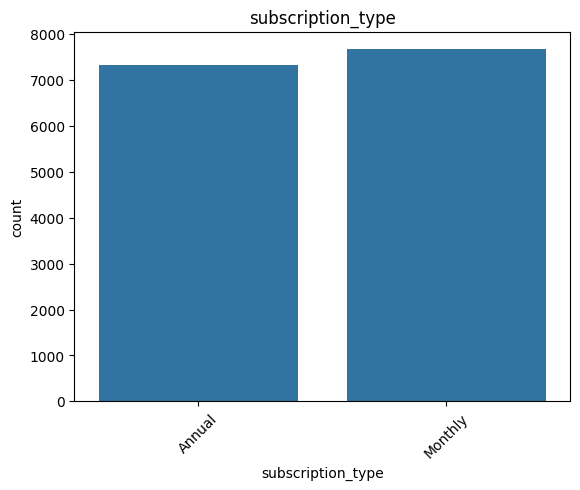

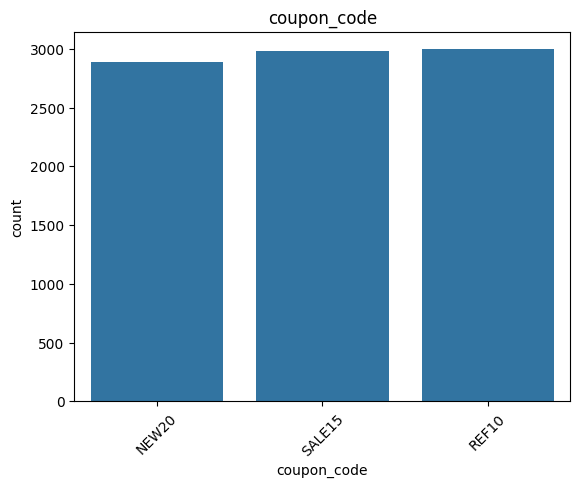

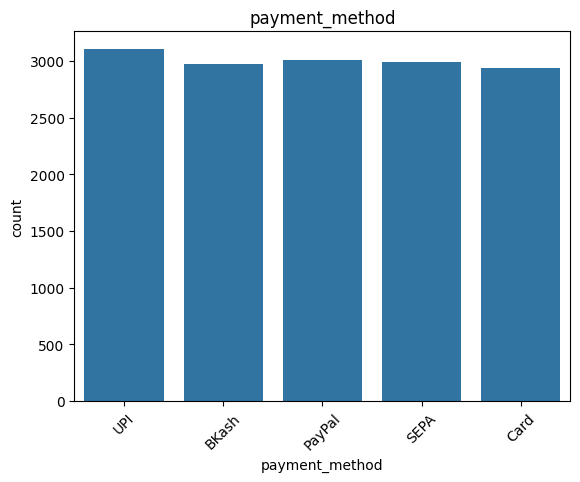

In [174]:
#distribusi kategorik
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

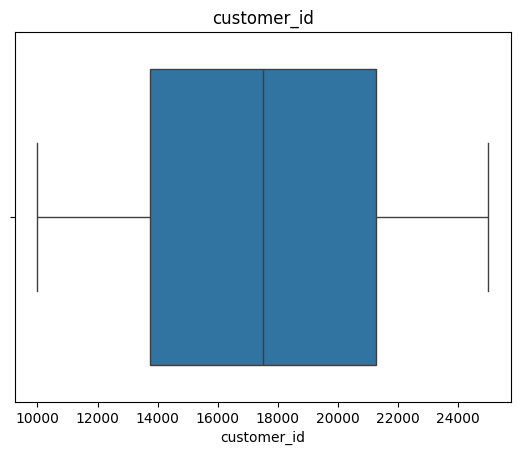

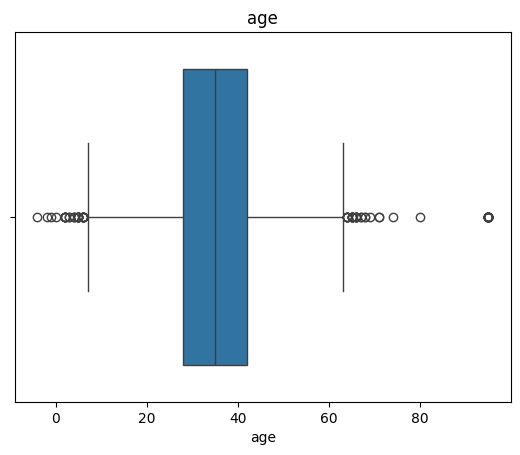

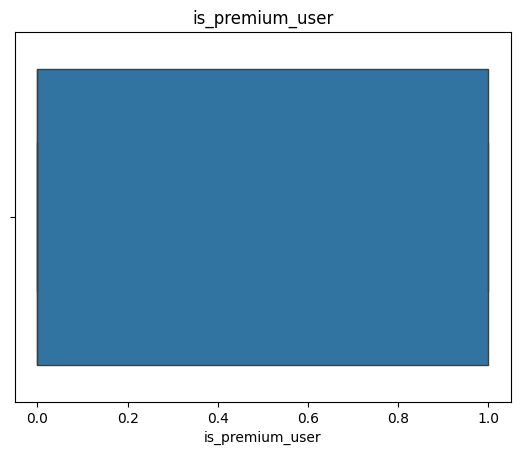

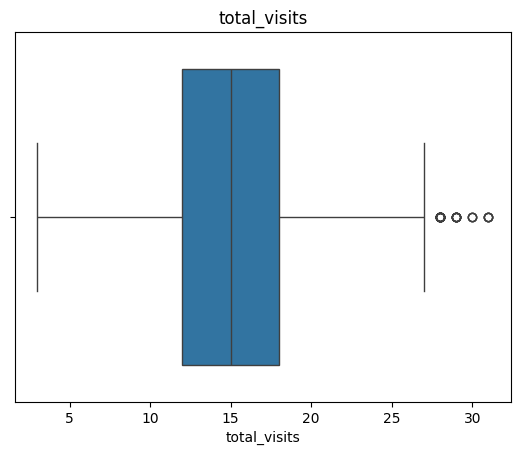

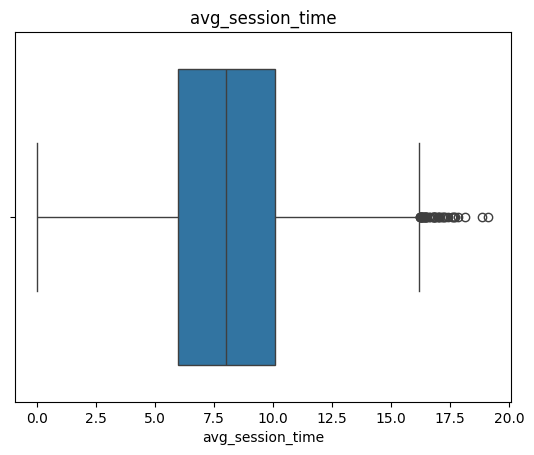

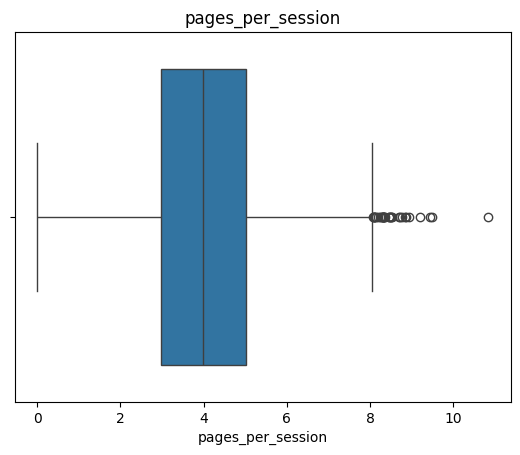

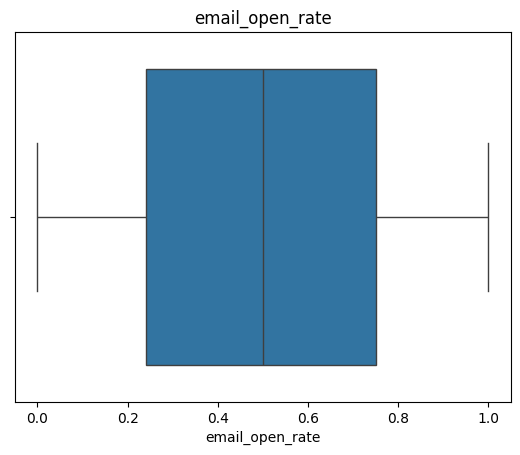

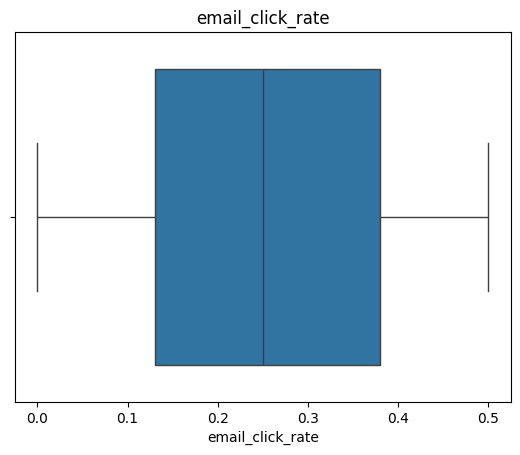

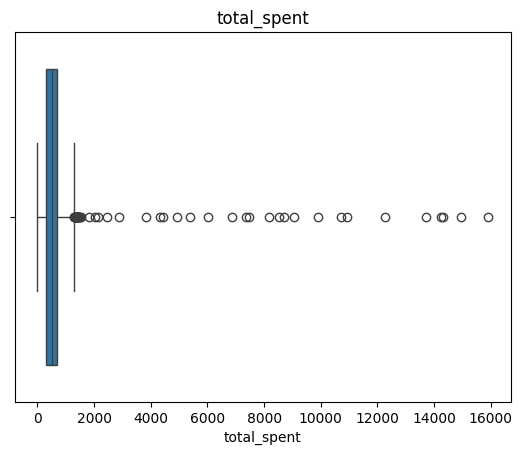

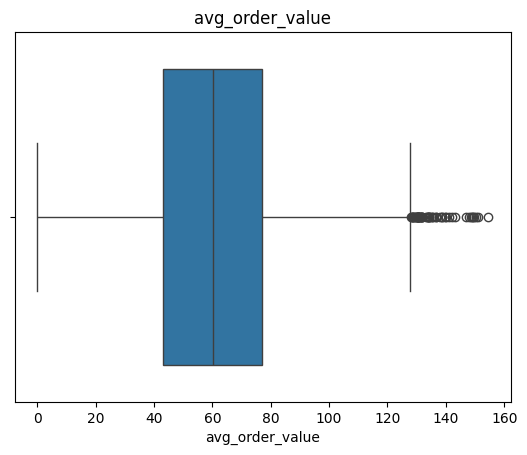

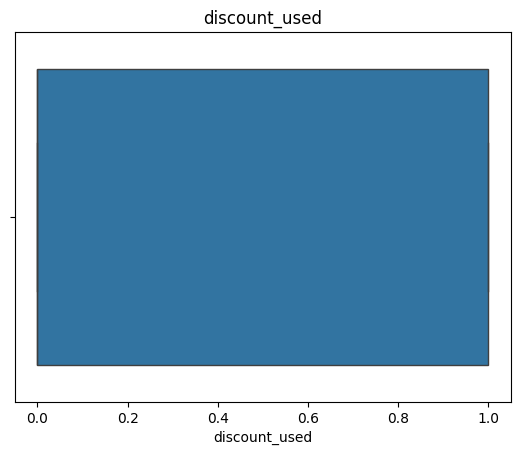

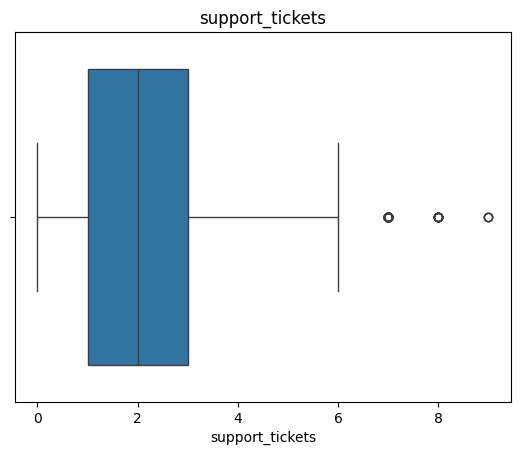

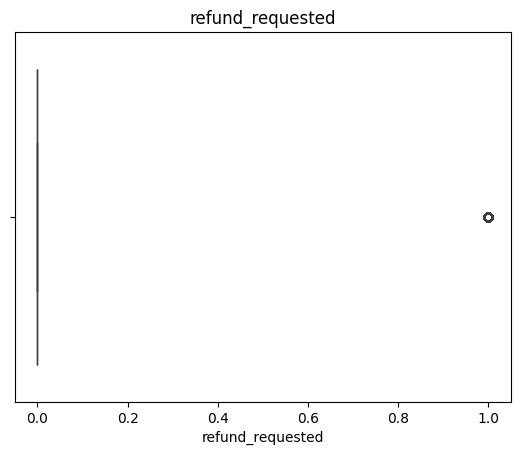

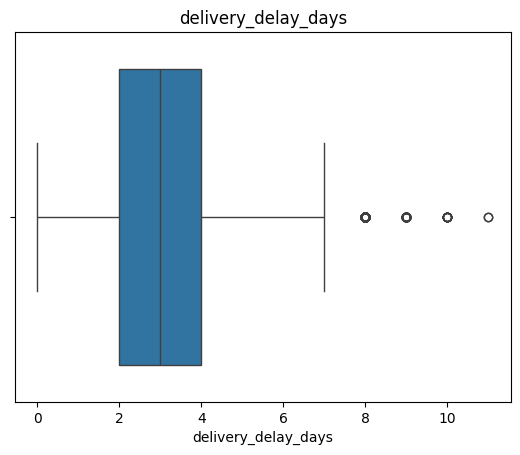

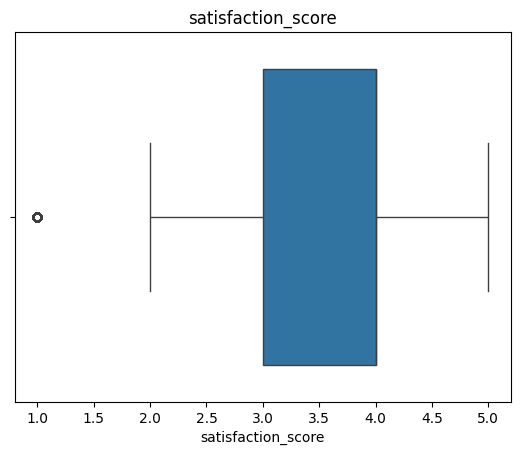

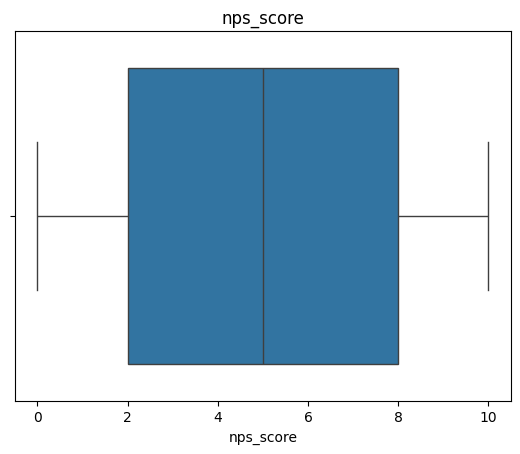

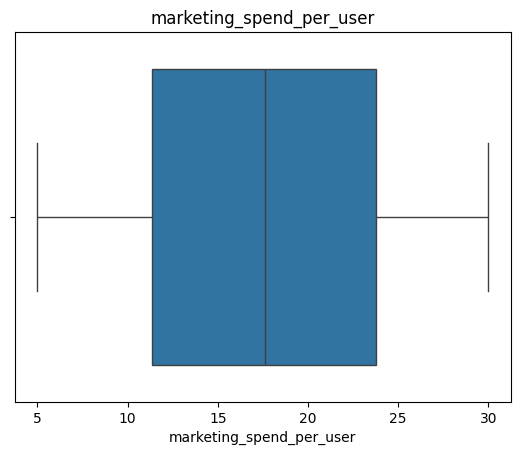

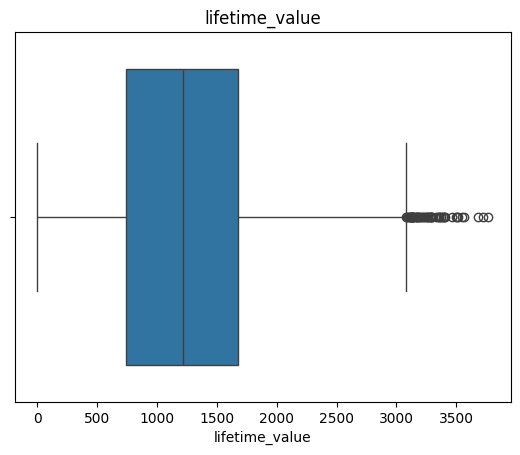

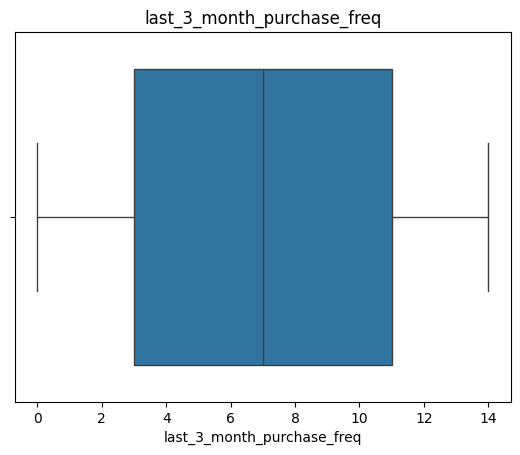

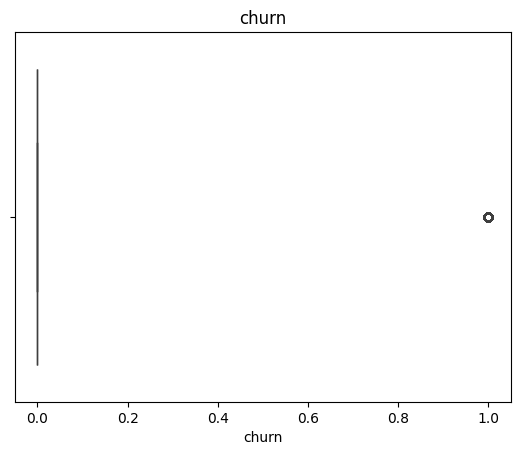

In [175]:
#outlier
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Berdasarkan hasil boxplot, ditemukan outlier dan akan dilakukan preprocessing

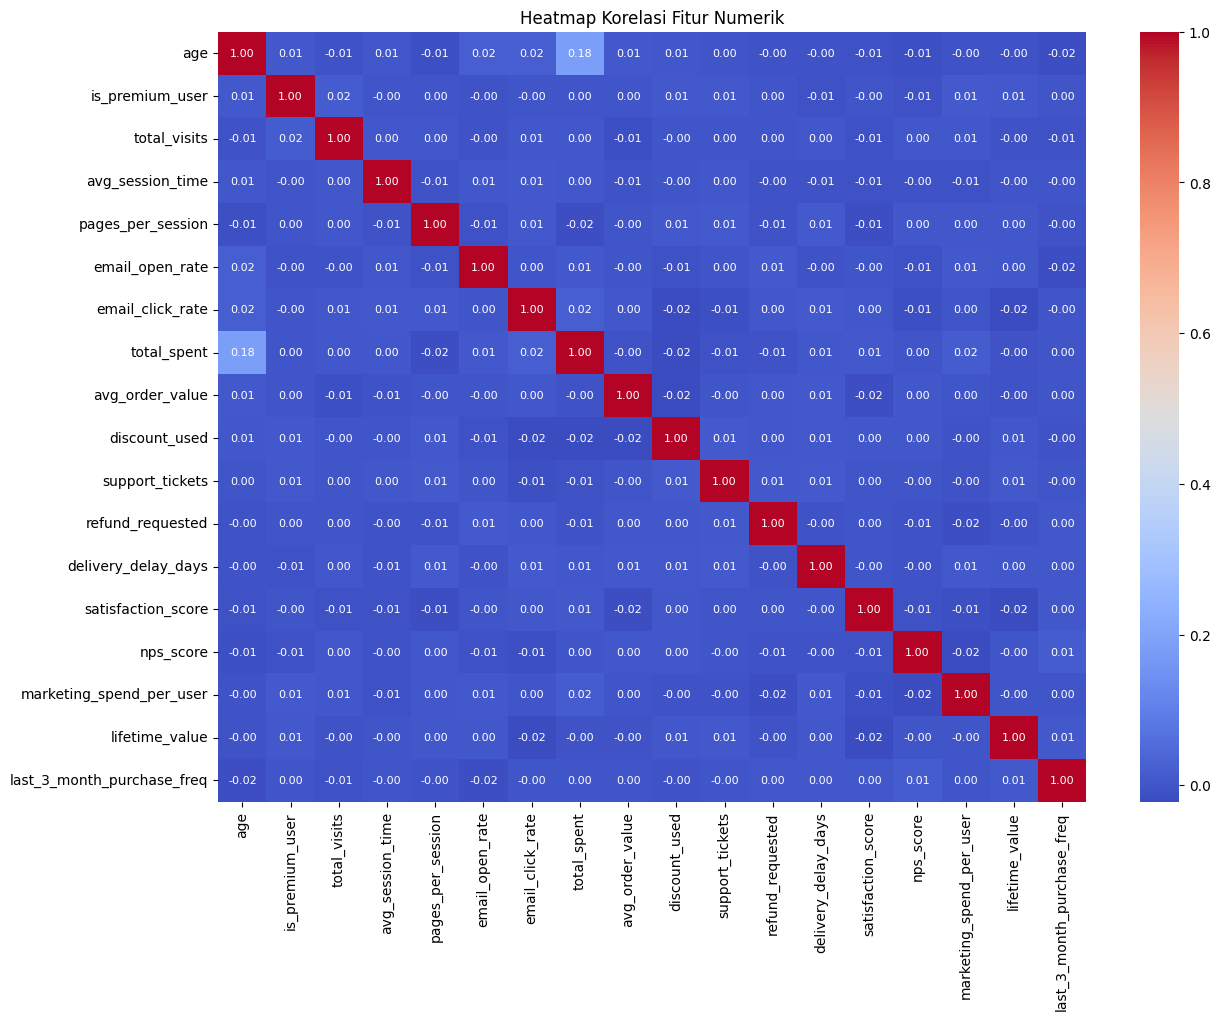

In [176]:
#korelasi
num_cols = [
    'age',
    'is_premium_user',
    'total_visits',
    'avg_session_time',
    'pages_per_session',
    'email_open_rate',
    'email_click_rate',
    'total_spent',
    'avg_order_value',
    'discount_used',
    'support_tickets',
    'refund_requested',
    'delivery_delay_days',
    'satisfaction_score',
    'nps_score',
    'marketing_spend_per_user',
    'lifetime_value',
    'last_3_month_purchase_freq'
]
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":8}
)

plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

## **DIRECT MODELING**

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

In [178]:
#data prepraration
df_model = df.copy()


In [190]:
# encoding kategorik
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])

In [191]:
from sklearn.model_selection import train_test_split

X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # untuk imbalance
)

In [192]:
print("Train:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

Train:
churn
0    10162
1     1838
Name: count, dtype: int64

Test:
churn
0    2540
1     460
Name: count, dtype: int64


In [193]:
num_cols = df_model.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('churn')

df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

In [194]:
print(df_model.isnull().sum())

customer_id                   0
gender                        0
age                           0
country                       0
city                          0
signup_date                   0
last_purchase_date            0
acquisition_channel           0
device_type                   0
subscription_type             0
is_premium_user               0
total_visits                  0
avg_session_time              0
pages_per_session             0
email_open_rate               0
email_click_rate              0
total_spent                   0
avg_order_value               0
discount_used                 0
coupon_code                   0
support_tickets               0
refund_requested              0
delivery_delay_days           0
payment_method                0
satisfaction_score            0
nps_score                     0
marketing_spend_per_user      0
lifetime_value                0
last_3_month_purchase_freq    0
churn                         0
dtype: int64


In [195]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
svm = SVC(probability=True)

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('svm', svm)
    ],
    voting='soft'   #  pakai soft voting
)

models = {
    "Logistic Regression": lr,          # konvensional
    "Random Forest": rf,                # ensemble bagging
    "Voting Classifier": voting         # gabungan model
}

 Model 1 — Konvensional: Logistic Regression

 Model 2 — Ensemble Bagging: Random Forest

 Model 3 — Ensemble Voting: Logistic Regression + SVM + KNN



===== Logistic Regression =====
Accuracy: 0.8476666666666667
              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2540
           1       0.51      0.15      0.24       460

    accuracy                           0.85      3000
   macro avg       0.69      0.56      0.58      3000
weighted avg       0.81      0.85      0.81      3000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


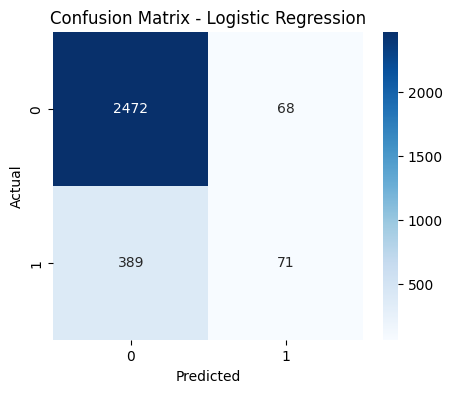


===== Random Forest =====
Accuracy: 0.8476666666666667
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2540
           1       0.51      0.31      0.39       460

    accuracy                           0.85      3000
   macro avg       0.69      0.63      0.65      3000
weighted avg       0.83      0.85      0.83      3000



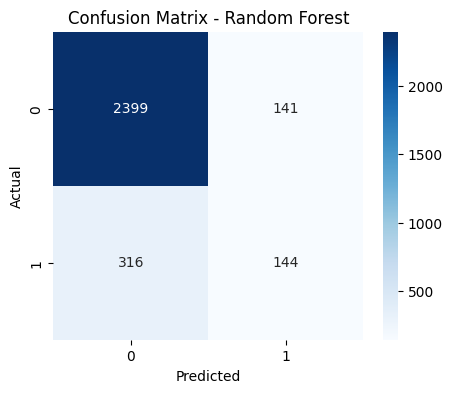


===== Voting Classifier =====


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    print(f"\n===== {name} =====")

    # training
    model.fit(X_train, y_train)

    # prediksi
    y_pred = model.predict(X_test)

    # evaluasi
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

# Modeling Dengan Preprocessing  

In [ ]:
from sklearn.preprocessing import StandardScaler

df_prep = df.copy()

In [ ]:
#handle missing
num_cols = df_prep.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['customer_id', 'churn'])
df_prep[num_cols] = df_prep[num_cols].fillna(df_prep[num_cols].median())
print(df_prep[num_cols].isnull().sum())

In [ ]:
# penghapusan outlier
features_to_clean = ['age']


for col in features_to_clean:
    # Menghitung Kuartil 1 (25%) dan Kuartil 3 (75%)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range
    IQR = Q3 - Q1

    # Menentukan Batas Bawah dan Batas Atas
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data: hanya ambil yang berada di dalam rentang batas
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Outlier telah dihapus.")

In [ ]:
#encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df_prep.select_dtypes(include='object').columns:
    df_prep[col] = le.fit_transform(df_prep[col])

In [ ]:
#slpit data
X = df_prep.drop('churn', axis=1)
y = df_prep['churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
#scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#hapus fitur tidak relevan
df_prep = df_prep.drop(['customer_id', 'gender'], axis=1)

In [ ]:
#smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
svm = SVC(probability=True)

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('svm', svm)
    ],
    voting='soft'   #  pakai soft voting
)

models = {
    "Logistic Regression": lr,          # konvensional
    "Random Forest": rf,                # ensemble bagging
    "Voting Classifier": voting         # gabungan model
}

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    print(f"\n===== {name} =====")

    # training
    model.fit(X_train, y_train)

    # prediksi
    y_pred = model.predict(X_test)

    # evaluasi
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

# Feature Selection

In [ ]:
df_fs = df_prep.copy()

In [ ]:
#fitur importance
from sklearn.ensemble import RandomForestClassifier

X = df_fs.drop('churn', axis=1)
y = df_fs['churn']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance)

In [ ]:
#visualisasi
import matplotlib.pyplot as plt

importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [ ]:
#ambil top fitur
top_features = importance.head(10).index
print("Top Features:")
print(top_features)

In [ ]:
df_fs['signup_date'] = pd.to_datetime(df_fs['signup_date'])
df_fs['last_purchase_date'] = pd.to_datetime(df_fs['last_purchase_date'])

# fitur baru
df_fs['customer_age_days'] = (pd.Timestamp.now() - df_fs['signup_date']).dt.days
df_fs['days_since_last_purchase'] = (pd.Timestamp.now() - df_fs['last_purchase_date']).dt.days

In [ ]:
df_fs = df_fs.drop(['signup_date', 'last_purchase_date'], axis=1)

In [ ]:
#fitur selection final
final_features = list(top_features)
print("Final Features:", final_features)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_fs.drop('churn', axis=1)
y = df_fs['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',   #  penting (imbalance)
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_res, y_train_res)

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Estimator:", grid.best_estimator_)

In [ ]:
best_model = grid.best_estimator_

best_model.fit(X_train_res, y_train_res)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_scaled)

# metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

# simpan model terbaik
joblib.dump(best_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')